# Dashboard V2 Analytics Playground

This notebook is a lightweight starting point for ad hoc analysis against the processed Parquet outputs.

It is designed to work without local raw CSV files as long as these files exist:

- `data/processed/consumer_master.parquet`
- `data/processed/consumption.parquet`
- `data/processed/vend.parquet`

The notebook also reuses the project analytics helpers so the exploratory outputs stay aligned with the Streamlit dashboard logic.

In [1]:
from __future__ import annotations

# Standard library imports for path resolution and repo-local imports.
from pathlib import Path
import sys

# Core analysis libraries used throughout the notebook.
import pandas as pd
import plotly.express as px
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    # Walk upward until we find the repository layout this notebook expects.
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src").exists() and (candidate / "config").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/ and config/.")


# Add the repo root to sys.path so local project modules can be imported.
PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: F:\Secure\CashFlowMgmt


In [2]:
from src.analytics import build_dashboard_analytics
from src.path_utils import load_app_config


# Load the same app config the Streamlit dashboard uses.
APP_CONFIG = load_app_config(PROJECT_ROOT / "config" / "app_config.yaml")
# Point to the processed-data folder so this notebook works without raw CSVs.
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

consumer_master_path = PROCESSED_DIR / "consumer_master.parquet"
consumption_path = PROCESSED_DIR / "consumption.parquet"
vend_path = PROCESSED_DIR / "vend.parquet"

# Quick existence check before trying to load the Parquet files.
for path in [consumer_master_path, consumption_path, vend_path]:
    print(path.name, "exists" if path.exists() else "missing", path)

# Load the processed datasets exactly as persisted by the dashboard pipeline.
consumer_master_df = pd.read_parquet(consumer_master_path)
consumption_df = pd.read_parquet(consumption_path)
vend_df = pd.read_parquet(vend_path)

# Rebuild the derived analytics layer so notebook outputs stay aligned with dashboard logic.
analytics = build_dashboard_analytics(
    master_df=consumer_master_df,
    vend_df=vend_df,
    consumption_df=consumption_df,
    app_config=APP_CONFIG,
)

# Pull out the most useful derived tables into short variable names for exploration.
consumer_summary = analytics["datasets"]["consumer_summary"]
vend_enriched = analytics["datasets"]["vend_enriched"]
consumption_enriched = analytics["datasets"]["consumption_enriched"]
exception_summary = analytics["exception_summary"]
portfolio_metrics = analytics["portfolio_metrics"]
vend_timestamp_quality = analytics["vend_timestamp_quality"]

consumer_master.parquet exists F:\Secure\CashFlowMgmt\data\processed\consumer_master.parquet
consumption.parquet exists F:\Secure\CashFlowMgmt\data\processed\consumption.parquet
vend.parquet exists F:\Secure\CashFlowMgmt\data\processed\vend.parquet


In [3]:
# High-level shape check for both the base and derived datasets.
dataset_overview = pd.DataFrame(
    [
        {"dataset": "consumer_master", "rows": len(consumer_master_df), "columns": len(consumer_master_df.columns)},
        {"dataset": "consumption", "rows": len(consumption_df), "columns": len(consumption_df.columns)},
        {"dataset": "vend", "rows": len(vend_df), "columns": len(vend_df.columns)},
        {"dataset": "consumer_summary", "rows": len(consumer_summary), "columns": len(consumer_summary.columns)},
    ]
)

# Portfolio metrics and vend timestamp quality are useful early sanity checks.
display(dataset_overview)
display(pd.DataFrame([portfolio_metrics]))
display(pd.DataFrame([vend_timestamp_quality]))

,dataset,rows,columns
0,consumer_master,1548361,38
1,consumption,580860,25
2,vend,1503445,19
3,consumer_summary,1548361,77


,total_consumers_in_master,total_distinct_meters_in_master,consumers_with_vend_records,consumers_with_consumption_records,vend_match_rate_pct,consumption_match_rate_pct,consumers_with_gis,consumers_with_feeder_dt,total_vend_transactions,total_consumption_rows,total_vend_amount,average_vend_amount,median_vend_amount,average_daily_kwh,average_daily_kvah
0,1548361,987408,463275,1,73.59,0.0,1060368,705111,1503445,580860,5.233909e+08,348.127732,100.0,637.415831,649.697211


,total_rows,full_datetime_rows,date_only_rows,time_only_rows,missing_rows,failed_rows,calendar_coverage_pct,quality_label,supports_daily_analysis,supports_intraday_analysis,note
0,1503445,1503445,0,0,0,0,100.0,full_datetime,True,True,Issuedate quality supports daily and intraday ...


## Quick checks

A few high-signal tables to sanity-check the processed outputs and the derived analytics layer.

In [4]:
# Exception summary gives the quickest view of operational hotspots.
display(exception_summary)
# Join coverage tables show how well vend and consumption resolve back to Consumer Master.
display(analytics["join_coverage"]["vend"]["coverage"])
display(analytics["join_coverage"]["consumption"]["coverage"])

# This watchlist surfaces consumers with higher exception scores and weaker balance positions.
consumer_summary[
    [
        "consumername",
        "consumernumber",
        "meterno",
        "meterbalance",
        "average_daily_kwh",
        "vend_transaction_count",
        "exception_score",
        "feedercode",
        "dtcode",
    ]
].sort_values(["exception_score", "meterbalance"], ascending=[False, True]).head(20)

,exception_type,consumer_count
0,Master records with no activity,1085085
1,Missing feeder or DT,843250
2,Missing GIS coordinates,487993
3,Vend but no consumption,463275
4,Critical balance customers,245739
5,Consumption but no vend,1
6,High average consumption with low balance,0
7,Low balance with consumption,0


,join_coverage_status,row_count,row_pct,dataset
0,both_keys_matched,702105,46.70,vend
1,consumer_only_matched,404292,26.89,vend
2,unmatched,397045,26.41,vend
3,meter_only_matched,3,0.00,vend


,join_coverage_status,row_count,row_pct,dataset
0,unmatched,580840,100.0,consumption
1,meter_only_matched,20,0.0,consumption


,consumername,consumernumber,meterno,meterbalance,average_daily_kwh,vend_transaction_count,exception_score,feedercode,dtcode
447174,RAGHUNATH HEADMAN,12240050351,NB10113146,-2182853.714,<NA>,0,4,<NA>,<NA>
650852,SARVOTAM KUMAR,123108111772,NB11865328,-1846739.52,<NA>,0,4,<NA>,<NA>
765325,WARD SAMITI PARBHANDHAK WARD NO -5,119103507268,NB11515987,-1298157.179,<NA>,0,4,<NA>,<NA>
795309,NIRDESH,11820003004,NB30019719,-1296619.325,<NA>,0,4,<NA>,<NA>
648788,EXECUTIVE ENGINEER PHED,12210126924,NB30023582,-611052.436,<NA>,2,4,<NA>,<NA>
310550,NAGAR AAYUKAT,118207922977,NB30010332,-522253.621,<NA>,0,4,<NA>,<NA>
145269,ASTT MECHANICAL ENGINEER,12210104556,NB30023014,-506000.889,<NA>,1,4,<NA>,<NA>
516704,"AASHA DEVI, W/O- LT. UMESH PRASAD",118204160166,NB10006094,-463869.403,<NA>,0,4,<NA>,<NA>
598525,SMT. ASHA DEVI,11820013862,NB10141287,-456279.797,<NA>,0,4,<NA>,<NA>
319587,VILASH PANDIT,120203555064,NB11014904,-418998.876,<NA>,0,4,<NA>,<NA>


## Example analysis: low balance by feeder

,feedercode,consumer_count,low_balance_count,critical_balance_count,average_daily_kwh
287,FD466,16917,5228,3564,<NA>
207,FD251,13865,4430,3050,<NA>
318,FD527,7963,3832,2837,<NA>
220,FD302,9370,3650,2610,<NA>
66,FD073,11434,3764,2545,<NA>
282,FD454,10634,3580,2512,<NA>
319,FD528,6249,3357,2478,<NA>
324,FD541,7395,3058,2305,<NA>
410,FD725,10133,3292,2190,<NA>
325,FD542,6779,2753,2130,<NA>


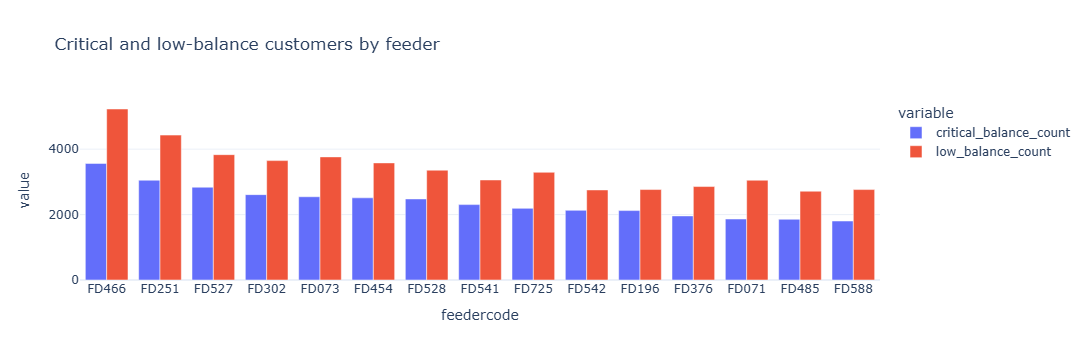

In [5]:
# Group the portfolio to see which feeders have the largest concentration of balance risk.
low_balance_by_feeder = (
    consumer_summary.dropna(subset=["feedercode"])
    .groupby("feedercode", dropna=True)
    .agg(
        consumer_count=("consumer_master_id", "size"),
        low_balance_count=("low_balance_flag", lambda s: int(s.fillna(False).sum())),
        critical_balance_count=("critical_balance_flag", lambda s: int(s.fillna(False).sum())),
        average_daily_kwh=("average_daily_kwh", "mean"),
    )
    .reset_index()
)

low_balance_by_feeder = low_balance_by_feeder.sort_values(
    ["critical_balance_count", "low_balance_count", "consumer_count"],
    ascending=[False, False, False],
)

# Show the raw summary table before plotting so it is easy to inspect exact values.
display(low_balance_by_feeder.head(20))

# A grouped bar chart helps compare critical vs broader low-balance exposure by feeder.
fig = px.bar(
    low_balance_by_feeder.head(15),
    x="feedercode",
    y=["critical_balance_count", "low_balance_count"],
    barmode="group",
    title="Critical and low-balance customers by feeder",
)
fig.update_layout(template="plotly_white")
fig.show()

## Example analysis: daily consumption trend

,date,kwh_consumption,kvah_consumption,rolling_7d_kwh
21,2026-01-22,11058003.999,11302581.32,1.147143e+07
22,2026-01-23,11263614.745,11514170.5,1.138843e+07
23,2026-01-24,11969514.838,12206221.521,1.139824e+07
24,2026-01-25,11141499.712,11387665.616,1.135220e+07
25,2026-01-26,11191618.332,11453588.857,1.129603e+07
26,2026-01-27,11089513.208,11345645.441,1.133439e+07
27,2026-01-28,10996819.135,11261675.422,1.124437e+07
28,2026-01-29,10990642.515,11239888.133,1.123475e+07
29,2026-01-30,10783799.987,11037137.049,1.116620e+07
30,2026-01-31,11280376.21,11511877.099,1.106775e+07


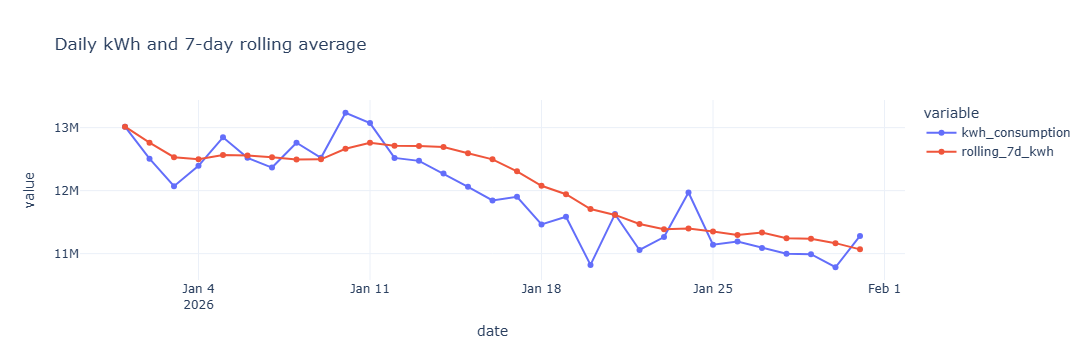

In [6]:
# Aggregate the enriched consumption fact table into a portfolio-wide daily time series.
daily_consumption = (
    consumption_enriched.groupby("date", dropna=True)[["kwh_consumption", "kvah_consumption"]]
    .sum(numeric_only=True)
    .reset_index()
    .sort_values("date")
)
# Rolling average smooths daily volatility and makes the overall trend easier to read.
daily_consumption["rolling_7d_kwh"] = daily_consumption["kwh_consumption"].rolling(7, min_periods=1).mean()

display(daily_consumption.tail(10))

# Plot both the raw daily series and the smoothed 7-day trend together.
fig = px.line(
    daily_consumption,
    x="date",
    y=["kwh_consumption", "rolling_7d_kwh"],
    markers=True,
    title="Daily kWh and 7-day rolling average",
)
fig.update_layout(template="plotly_white")
fig.show()

## Example analysis: vend patterns

,vend_date,transactionamount_numeric
20,2026-01-21,19524373.25
21,2026-01-22,22984777.81
22,2026-01-23,17293696.85
23,2026-01-24,10705876.77
24,2026-01-25,6597861.0
25,2026-01-26,9780166.43
26,2026-01-27,35573412.52
27,2026-01-28,17664284.04
28,2026-01-29,22549469.29
29,2026-01-30,16068956.31


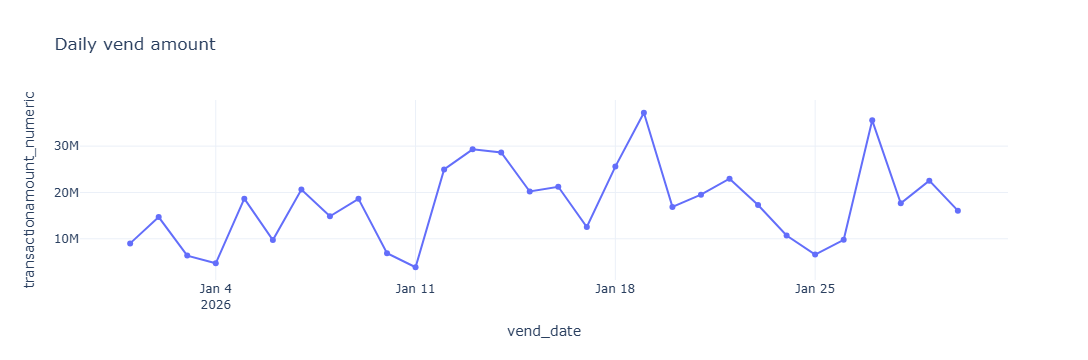

In [7]:
# Work on a copy so ad hoc numeric conversions do not mutate the shared enriched frame.
vend_work = vend_enriched.copy()
# Keep vend amounts numeric for aggregation and plotting.
vend_work["transactionamount_numeric"] = pd.to_numeric(vend_work["transactionamount"], errors="coerce")

# Choose the safest analysis path based on issuedate quality.
if vend_timestamp_quality["supports_daily_analysis"]:
    # When calendar dates are reliable, aggregate to a daily vend series.
    daily_vend = (
        vend_work.dropna(subset=["vend_date"])
        .groupby("vend_date", dropna=True)["transactionamount_numeric"]
        .sum()
        .reset_index()
        .sort_values("vend_date")
    )
    display(daily_vend.tail(10))
    fig = px.line(
        daily_vend,
        x="vend_date",
        y="transactionamount_numeric",
        markers=True,
        title="Daily vend amount",
    )
else:
    # If date quality is weak, fall back to hour-of-day patterns instead of faking a calendar trend.
    hourly_vend = (
        vend_work.dropna(subset=["analysis_hour"])
        .groupby("analysis_hour", dropna=True)["transactionamount_numeric"]
        .sum()
        .reset_index()
        .sort_values("analysis_hour")
    )
    display(hourly_vend)
    fig = px.bar(
        hourly_vend,
        x="analysis_hour",
        y="transactionamount_numeric",
        title="Time-of-day vend amount",
    )

# Use the same clean white template as the dashboard charts.
fig.update_layout(template="plotly_white")
fig.show()

## Example analysis: workbench cell

Use this final cell for your own joins, aggregations, plots, or exports.

In [8]:
# Example starter snippets:
# Use these to discover available fields before writing a custom analysis.
# consumer_summary.columns.tolist()
# vend_enriched.columns.tolist()
# consumption_enriched.columns.tolist()

# your analysis here